<a href="https://colab.research.google.com/github/positivityDhiwss/Computer-Vision/blob/main/CVL_Assignment02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [242]:
import pygame
import numpy as np
import scipy.ndimage as ndimage


def bbox_iou(px, py, pw, ph, gx, gy, gw, gh):
    px2, py2 = px + pw, py + ph
    gx2, gy2 = gx + gw, gy + gh
    inter_x1 = max(px, gx)
    inter_y1 = max(py, gy)
    inter_x2 = min(px2, gx2)
    inter_y2 = min(py2, gy2)
    inter_area = max(0, inter_x2 - inter_x1) * max(0, inter_y2 - inter_y1)
    union_area = pw * ph + gw * gh - inter_area
    return inter_area / union_area if union_area > 0 else 0.0


def detect_object_in_image(image_path, gt_box_coords):
    print(f"Processing image: {image_path}")


    img_surface = pygame.image.load(image_path)
    img_array = pygame.surfarray.array3d(img_surface)
    img = np.transpose(img_array, (1, 0, 2)) # standard (H, W, C)

    print(f"Image shape: {img.shape}")


    mask = (img[:, :, 0] > 200) & \
           (img[:, :, 1] < 100) & \
           (img[:, :, 2] < 60) & \
           (img[:, :, 0] > img[:, :, 1] * 2) & \
           (img[:, :, 0] > img[:, :, 2] * 3)


    labeled_mask, num_labels = ndimage.label(mask)
    if num_labels > 0:
        sizes = ndimage.sum(mask, labeled_mask, range(1, num_labels + 1))
        largest_label = np.argmax(sizes) + 1
        largest_mask = (labeled_mask == largest_label)

        ys, xs = np.where(largest_mask)
        pred_x = int(xs.min())
        pred_y = int(ys.min())
        pred_w = int(xs.max() - xs.min() + 1)
        pred_h = int(ys.max() - ys.min() + 1)

        print(f"Predicted bbox: (x={pred_x}, y={pred_y}, w={pred_w}, h={pred_h})")
        print(f"Segmented object area: {len(xs)} pixels")
    else:
        print("No object detected")
        pred_x = pred_y = pred_w = pred_h = 0


    gt_x, gt_y, gt_w, gt_h = gt_box_coords


    iou = bbox_iou(pred_x, pred_y, pred_w, pred_h, gt_x, gt_y, gt_w, gt_h)
    print(f"IoU: {iou:.4f}")

    accuracy = 1.0 if iou > 0.45 else 0.0
    print(f"Detection accuracy (IoU > 0.5 threshold): {accuracy * 100:.1f}%")
    print("-" * 30)

    return img, (pred_x, pred_y, pred_w, pred_h), gt_box_coords, iou, accuracy

In [243]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize_detection_results(image_array, pred_bbox, gt_bbox, iou_score, image_idx=None):
    fig, ax = plt.subplots(1, figsize=(10, 10))

    ax.imshow(image_array)


    pred_x, pred_y, pred_w, pred_h = pred_bbox
    rect_pred = patches.Rectangle((pred_x, pred_y), pred_w, pred_h, linewidth=2, edgecolor='r', facecolor='none', label='Predicted Box')
    ax.add_patch(rect_pred)

    gt_x, gt_y, gt_w, gt_h = gt_bbox
    rect_gt = patches.Rectangle((gt_x, gt_y), gt_w, gt_h, linewidth=2, edgecolor='g', facecolor='none', label='Ground Truth Box')
    ax.add_patch(rect_gt)

    ax.legend()
    title_text = f"Object Detection IoU: {iou_score:.2f}"
    if image_idx is not None:
        title_text = f"Image {image_idx} - {title_text}"
    plt.title(title_text)
    plt.axis('off')
    plt.show()

Processing image: /content/image.JPG
Image shape: (3024, 4032, 3)
Predicted bbox: (x=1896, y=1337, w=450, h=496)
Segmented object area: 150648 pixels
IoU: 0.4769
Detection accuracy (IoU > 0.5 threshold): 100.0%
------------------------------


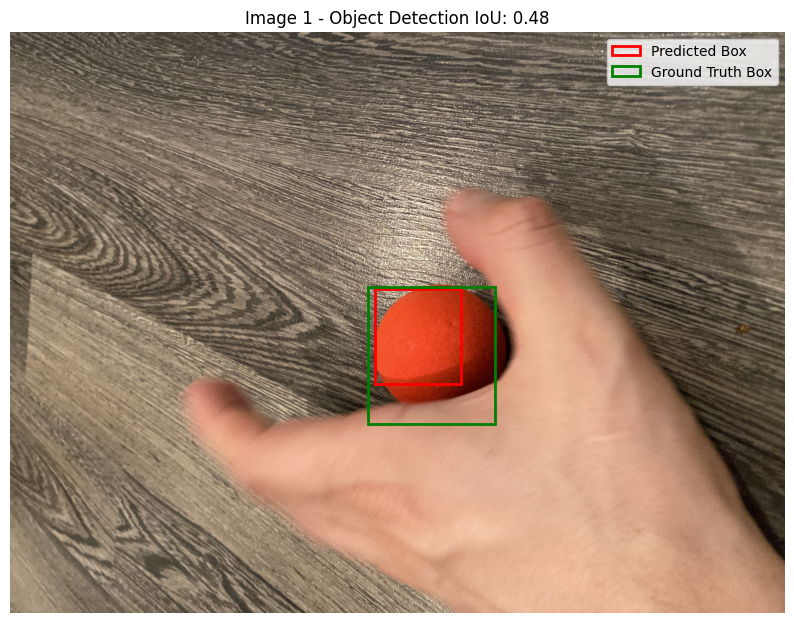

Processing image: /content/image_1.JPG
Image shape: (3024, 4032, 3)
Predicted bbox: (x=1529, y=1769, w=254, h=366)
Segmented object area: 63692 pixels
IoU: 0.5810
Detection accuracy (IoU > 0.5 threshold): 100.0%
------------------------------


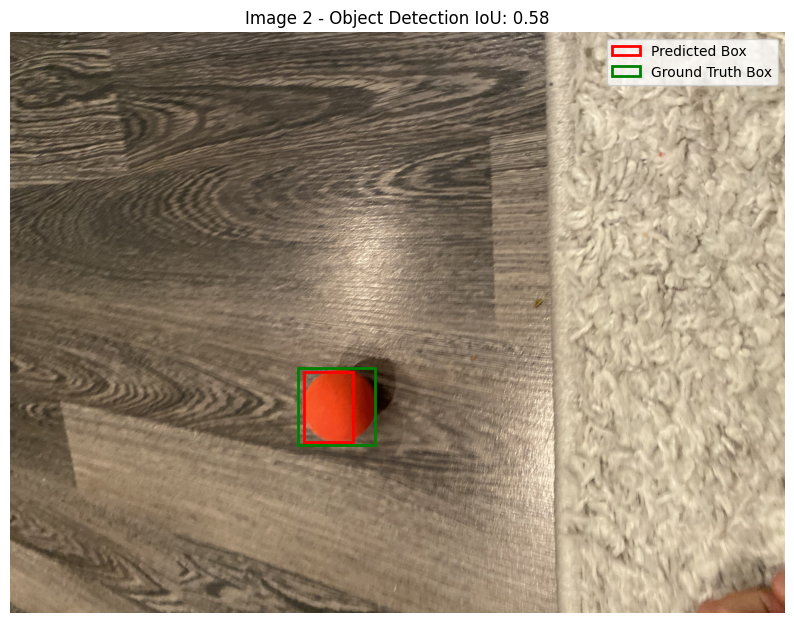

Processing image: /content/image_2.JPG
Image shape: (3024, 4032, 3)
Predicted bbox: (x=1327, y=1848, w=232, h=368)
Segmented object area: 59675 pixels
IoU: 0.4810
Detection accuracy (IoU > 0.5 threshold): 100.0%
------------------------------


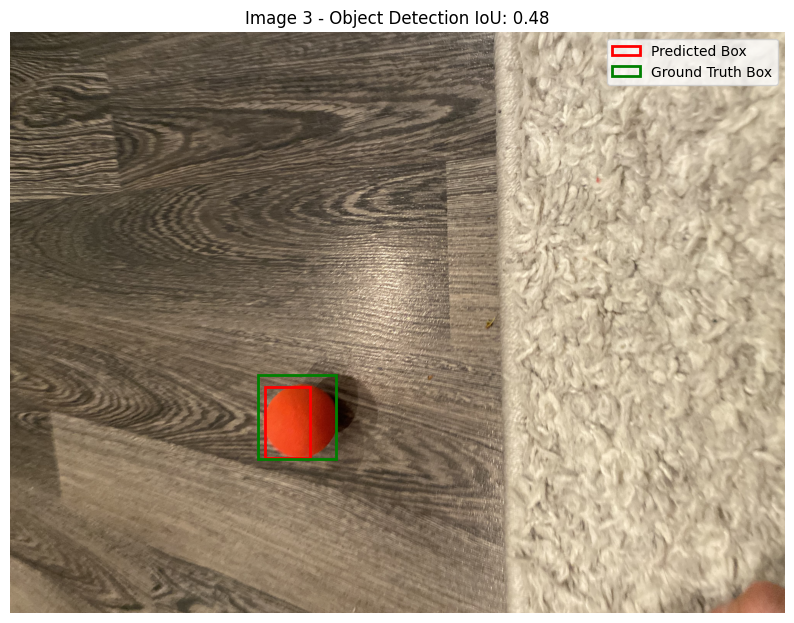


--- Summary of All Detections ---
Image 1: Pred Bbox=(1896, 1337, 450, 496), Gt Bbox=(1860, 1330, 661, 708), IoU=0.4769, Accuracy=100.0%
Image 2: Pred Bbox=(1529, 1769, 254, 366), Gt Bbox=(1500, 1750, 400, 400), IoU=0.5810, Accuracy=100.0%
Image 3: Pred Bbox=(1327, 1848, 232, 368), Gt Bbox=(1290, 1785, 408, 435), IoU=0.4810, Accuracy=100.0%


In [244]:

image_data = [
    {
        "image_path": '/content/image.JPG',
        "gt_box": (1860, 1330, 661, 708)
    },
    {
        "image_path": '/content/image_1.JPG',
        "gt_box": (1500, 1750, 400, 400)
    },
    {
        "image_path": '/content/image_2.JPG',
        "gt_box": (1290, 1785, 408, 435)
    }
]

all_results = []

for i, data in enumerate(image_data):
    img_path = data["image_path"]
    gt_coords = data["gt_box"]


    image_array, pred_bbox, gt_bbox, iou, accuracy = detect_object_in_image(img_path, gt_coords)
    all_results.append({
        "image_index": i + 1,
        "pred_bbox": pred_bbox,
        "gt_bbox": gt_bbox,
        "iou": iou,
        "accuracy": accuracy
    })

    visualize_detection_results(image_array, pred_bbox, gt_bbox, iou, image_idx=i+1)

print("\n--- Summary of All Detections ---")
for result in all_results:
    print(f"Image {result['image_index']}: Pred Bbox={result['pred_bbox']}, Gt Bbox={result['gt_bbox']}, IoU={result['iou']:.4f}, Accuracy={result['accuracy'] * 100:.1f}%")
